# Segmentação de Clientes com Aprendizado Não Supervisionado

**UNISINOS — Aprendizado Não Supervisionado**
Atividade Prática: K-Means, Clustering Hierárquico e DBSCAN aplicados ao **UCI Online Retail Dataset**.

Este notebook segue o seguinte pipeline:

`Explorar → Engenharia (RFM) → Transformar (log1p + Scaler) → Agrupar (K-Means, Hierárquico, DBSCAN) → Avaliar (silhueta, Davies-Bouldin, estabilidade) → Visualizar (PCA, radar, heatmap) → Traduzir (nomear, dimensionar, propor ação)`

| Seção | Conteúdo | Item da atividade |
|---|---|---|
| 1 | Carga e EDA | — |
| 2 | Engenharia de features (RFM) | — |
| 3 | Preparação (padronização e escala) | Item 1 |
| 4 | K-Means, Hierárquico, DBSCAN + métricas | **Item 1** |
| 5 | Diagnóstico de confiança | Item 1 |
| 6 | Visualizações (PCA, radar, heatmap, distribuição) | **Item 2** |
| 7 | Nomeação e tradução para negócio | Item 2/3 |
| 8 | Insumos numéricos para o relatório | Item 3 |

**Dataset esperado:** `data/online_retail.xlsx` (ou `.csv`), com as colunas originais do UCI Online Retail:
`InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country`.
Ajuste `DATA_PATH` na célula de setup para o caminho local do arquivo.

**Item 3 (Relatório Executivo):** documento separado, `relatorio_executivo.docx` — este notebook só calcula os números que entram nele (seção 8).

## 0 · Setup

Bibliotecas, semente fixa e paleta institucional (mesmo padrão das Aulas 01/02, para manter as figuras consistentes).

In [709]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

warnings.filterwarnings("ignore")

# semente única, reutilizada em toda inicialização aleatória do notebook —
# garante que o mesmo agrupamento seja reproduzido em uma nova execução
# (ver discussão sobre reprodutibilidade x estabilidade na seção 5)
RS = 42
np.random.seed(RS)

PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]
CINZA_RUIDO = "#B8C4CE"

def cores(labels):
    '''Mapeia rótulos de cluster para cores da paleta; ruído (-1, do DBSCAN) fica cinza.'''
    return np.array([CINZA_RUIDO if l == -1 else PALETA[int(l) % len(PALETA)] for l in labels])

plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

# caminho local do dataset — ajustar conforme onde o arquivo foi salvo
DATA_PATH = "data/online_retail.xlsx"  # aceita também .csv

## 1 · Carga dos dados e EDA inicial

UCI Online Retail: transações de um varejo online do Reino Unido (dez/2010–dez/2011).
Colunas originais: `InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country`.

In [710]:
if DATA_PATH.endswith(".csv"):
    df_raw = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")
else:
    df_raw = pd.read_excel(DATA_PATH)

print(f"linhas: {len(df_raw):,}  |  colunas: {list(df_raw.columns)}")
df_raw.info()
df_raw.head()

linhas: 541,909  |  colunas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [711]:
# panorama de qualidade dos dados — decide o que precisa de tratamento antes do RFM
resumo_qualidade = pd.DataFrame({
    "nulos": df_raw.isna().sum(),
    "nulos_%": (df_raw.isna().mean() * 100).round(2),
})
print(resumo_qualidade)
print()
print(f"CustomerID nulo: {df_raw['CustomerID'].isna().mean():.1%} das linhas")
print(f"Quantity <= 0  : {(df_raw['Quantity'] <= 0).mean():.1%} das linhas")
print(f"UnitPrice <= 0 : {(df_raw['UnitPrice'] <= 0).mean():.1%} das linhas")
print(f"InvoiceNo com prefixo 'C' (cancelamento): {df_raw['InvoiceNo'].astype(str).str.startswith('C').mean():.1%}")

              nulos  nulos_%
InvoiceNo         0     0.00
StockCode         0     0.00
Description    1454     0.27
Quantity          0     0.00
InvoiceDate       0     0.00
UnitPrice         0     0.00
CustomerID   135080    24.93
Country           0     0.00

CustomerID nulo: 24.9% das linhas
Quantity <= 0  : 2.0% das linhas
UnitPrice <= 0 : 0.5% das linhas
InvoiceNo com prefixo 'C' (cancelamento): 1.7%


In [712]:
# limpeza — cada filtro remove uma fonte de ruído específica para o RFM:
# CustomerID nulo -> não é possível atribuir a um cliente;
# InvoiceNo 'C...' -> pedido cancelado, não é receita realizada;
# Quantity/UnitPrice <= 0 -> devoluções e lançamentos de ajuste, não venda
df = df_raw.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(f"linhas após limpeza: {len(df):,}  ({len(df) / len(df_raw):.1%} do bruto)")
print(f"clientes únicos    : {df['CustomerID'].nunique():,}")
print(f"período            : {df['InvoiceDate'].min().date()} a {df['InvoiceDate'].max().date()}")
print(f"países             : {df['Country'].nunique()}")
df["Country"].value_counts().head(10)

linhas após limpeza: 397,884  (73.4% do bruto)
clientes únicos    : 4,338
período            : 2010-12-01 a 2011-12-09
países             : 37


Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

## 2 · Engenharia de features — RFM

* **Recency** — dias desde a última compra até a data de referência.
* **Frequency** — número de pedidos (invoices) distintos.
* **Monetary** — valor total gasto.

**Cuidado com viés de amostragem temporal (look-ahead bias):** a data de referência é fixa em `max(InvoiceDate) + 1 dia` — nunca a data de execução do notebook, nem uma janela centrada.
Todo cliente é medido a partir do mesmo ponto no tempo, com apenas dados até esse ponto.

In [713]:
data_referencia = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"data de referência (fixa): {data_referencia.date()}")

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda s: (data_referencia - s.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

FEATURES = ["Recency", "Frequency", "Monetary"]
clientes_com_id = df_raw["CustomerID"].dropna().nunique()
clientes_fora = clientes_com_id - len(rfm)
print(f"clientes na base RFM: {len(rfm):,}")
print(f"clientes com ID mas fora do RFM (só cancelamentos/lançamentos inválidos): {clientes_fora:,}")
rfm[FEATURES].describe().round(1)

data de referência (fixa): 2011-12-10
clientes na base RFM: 4,338
clientes com ID mas fora do RFM (só cancelamentos/lançamentos inválidos): 34


,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0
mean,92.5,4.3,2054.3
std,100.0,7.7,8989.2
min,1.0,1.0,3.8
25%,18.0,1.0,307.4
50%,51.0,2.0,674.5
75%,142.0,5.0,1661.7
max,374.0,209.0,280206.0


assimetria (skew) antes de qualquer transformação:
Recency       1.25
Frequency    12.07
Monetary     19.32
dtype: float64


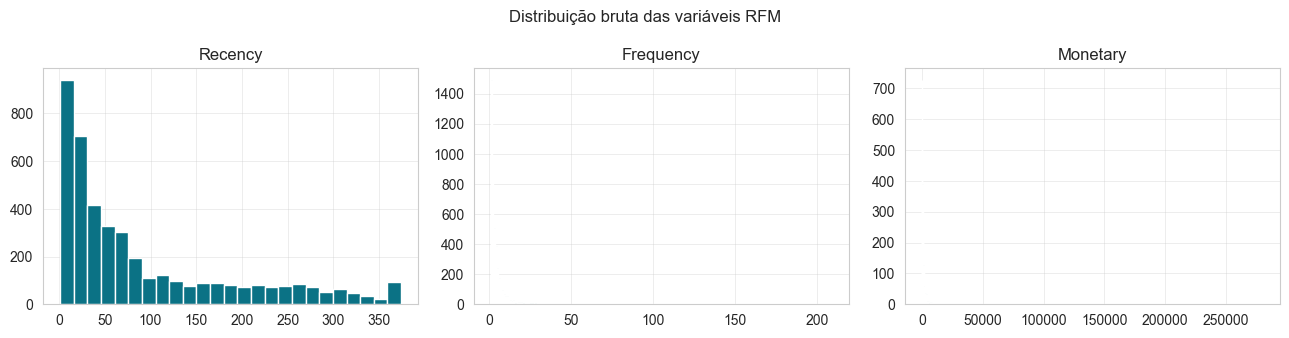

In [714]:
# assimetria das três variáveis — Monetary e Frequency tendem a ter cauda longa
# em dados de varejo (poucos clientes concentram grande parte do valor/volume)
print("assimetria (skew) antes de qualquer transformação:")
print(rfm[FEATURES].skew().round(2))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, f in zip(axes, FEATURES):
    ax.hist(rfm[f], bins="auto", color=PALETA[0])
    ax.set_title(f)
fig.suptitle("Distribuição bruta das variáveis RFM")
fig.tight_layout()
plt.show()

## 3 · Preparação dos dados

Duas transformações, nessa ordem:

1. **`log1p`** — reduz a assimetria de Monetary/Frequency (quase obrigatório para valores monetários).
2. **`StandardScaler`** — coloca as três variáveis na mesma escala antes de qualquer método baseado em distância.

Abaixo, uma demonstração com os dados reais: o mesmo K-Means, nos mesmos dados, muda de qualidade dependendo só da preparação.

assimetria após log1p:
Recency     -0.38
Frequency    1.21
Monetary     0.39
dtype: float64


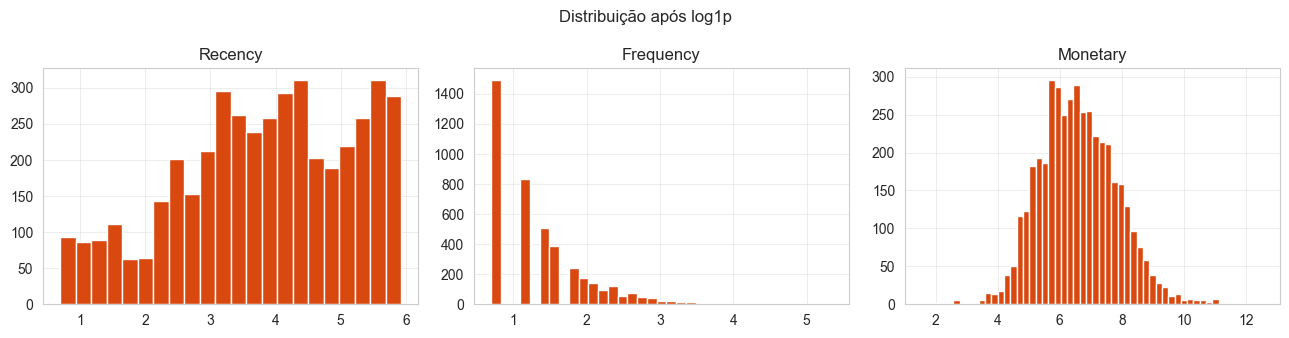

In [715]:
X_log = np.log1p(rfm[FEATURES].values)
print("assimetria após log1p:")
print(pd.DataFrame(X_log, columns=FEATURES).skew().round(2))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, f, dados in zip(axes, FEATURES, X_log.T):
    ax.hist(dados, bins="auto", color=PALETA[1])
    ax.set_title(f)
fig.suptitle("Distribuição após log1p")
fig.tight_layout()
plt.show()

scaler = StandardScaler().fit(X_log)  # guardar este scaler junto do modelo final —
Z = scaler.transform(X_log)           # é ele que pontua um cliente novo

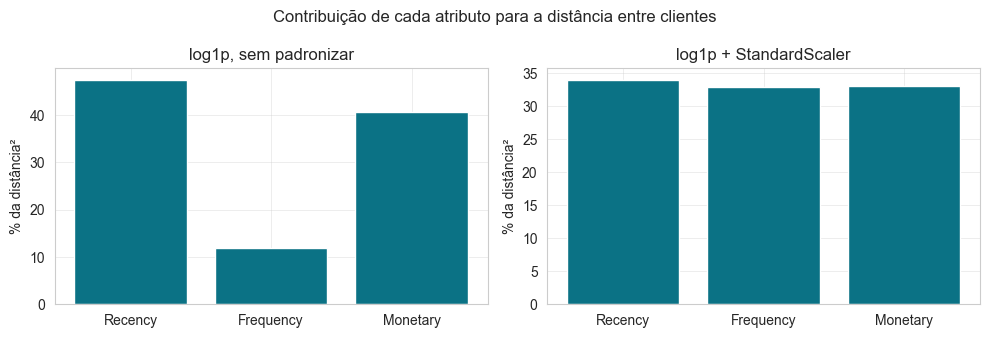

silhouette sem padronizar : 0.348
silhouette com padronizar : 0.337


In [716]:
# log1p aplicado em ambos os casos, para isolar o efeito da ESCALA
# (e não confundir com o efeito da assimetria, que já foi corrigido nos dois)
def fracao_da_distancia(X, cols, n_pares=6000, seed=RS):
    '''Quanto cada atributo contribui, em média, para a distância² entre dois clientes.'''
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=(n_pares, 2))
    d2 = (X[idx[:, 0]] - X[idx[:, 1]]) ** 2
    return pd.Series(d2.sum(axis=0) / d2.sum(), index=cols)

frac_sem = fracao_da_distancia(X_log, FEATURES)
frac_com = fracao_da_distancia(Z, FEATURES)

km_sem = KMeans(4, n_init=10, random_state=RS).fit(X_log)
km_com = KMeans(4, n_init=10, random_state=RS).fit(Z)
sil_sem = silhouette_score(X_log, km_sem.labels_)
sil_com = silhouette_score(Z, km_com.labels_)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, frac, titulo in zip(axes, [frac_sem, frac_com], ["log1p, sem padronizar", "log1p + StandardScaler"]):
    ax.bar(frac.index, frac.values * 100, color=PALETA[0])
    ax.set_ylabel("% da distância²")
    ax.set_title(titulo)
fig.suptitle("Contribuição de cada atributo para a distância entre clientes")
fig.tight_layout()
plt.show()

print(f"silhouette sem padronizar : {sil_sem:.3f}")
print(f"silhouette com padronizar : {sil_com:.3f}")

> **Leitura do resultado:** se `Monetary` concentra a maior parte da distância antes do `StandardScaler`, o agrupamento "sem padronizar" está, na prática, segmentando só por valor gasto — Recency e Frequency somem do cálculo mesmo aparecendo no código. A partir daqui, todo o notebook usa `Z` (log1p + StandardScaler).

## 4 · Item 1 — Implementação e comparação de algoritmos

Estrutura de resultados única para os três algoritmos, permitindo comparação direta ao final.

In [717]:
resultados = {
    "algoritmo": [], "n_clusters": [], "silhouette": [],
    "davies_bouldin": [], "calinski_harabasz": [], "tempo_execucao_s": [],
}

def registrar(nome, labels, X, tempo, apenas_nao_ruido=False):
    if apenas_nao_ruido:
        mask = labels != -1
        n_clusters = len(set(labels[mask]))
        if n_clusters < 2 or mask.sum() <= n_clusters:
            sil = db_score = ch_score = np.nan
        else:
            sil = silhouette_score(X[mask], labels[mask])
            db_score = davies_bouldin_score(X[mask], labels[mask])
            ch_score = calinski_harabasz_score(X[mask], labels[mask])
    else:
        n_clusters = len(set(labels))
        sil = silhouette_score(X, labels)
        db_score = davies_bouldin_score(X, labels)
        ch_score = calinski_harabasz_score(X, labels)
    resultados["algoritmo"].append(nome)
    resultados["n_clusters"].append(n_clusters)
    resultados["silhouette"].append(sil)
    resultados["davies_bouldin"].append(db_score)
    resultados["calinski_harabasz"].append(ch_score)
    resultados["tempo_execucao_s"].append(tempo)

### 4.1 · K-Means — escolha de K

Três perspectivas, nenhuma decide sozinha: cotovelo (inércia), silhueta e **estabilidade** (o cluster sobrevive à reamostragem?). O K final é desempatado por viabilidade de negócio — quantos segmentos a operação de marketing consegue de fato tratar de forma diferente.

In [718]:
def estabilidade(X, k, n_rep=20, frac=0.8, seed=RS):
    '''Reamostra 80% dos dados n_rep vezes; mede a concordância (ARI) com o agrupamento de referência.'''
    r = np.random.default_rng(seed)
    ref = KMeans(k, n_init=10, random_state=seed).fit(X)
    scores = []
    for _ in range(n_rep):
        idx = r.choice(len(X), size=int(frac * len(X)), replace=False)
        lab_amostra = KMeans(k, n_init=10, random_state=seed).fit_predict(X[idx])
        scores.append(adjusted_rand_score(ref.labels_[idx], lab_amostra))
    return np.mean(scores)

ks = range(2, 11)
inercia, silhueta_k, estab_k = [], [], []
for k in ks:
    m = KMeans(k, n_init=10, random_state=RS).fit(Z)
    inercia.append(m.inertia_)
    silhueta_k.append(silhouette_score(Z, m.labels_))
    estab_k.append(estabilidade(Z, k))

tabela_k = pd.DataFrame({
    "k": list(ks), "inercia": np.round(inercia, 1),
    "silhueta": np.round(silhueta_k, 3), "estabilidade_ARI": np.round(estab_k, 3),
})
tabela_k

,k,inercia,silhueta,estabilidade_ARI
0,2,6481.2,0.433,0.989
1,3,4867.8,0.337,0.947
2,4,3938.5,0.337,0.923
3,5,3296.0,0.316,0.896
4,6,2855.0,0.313,0.926
5,7,2548.9,0.310,0.952
6,8,2336.8,0.301,0.814
7,9,2155.6,0.282,0.858
8,10,1999.9,0.279,0.820


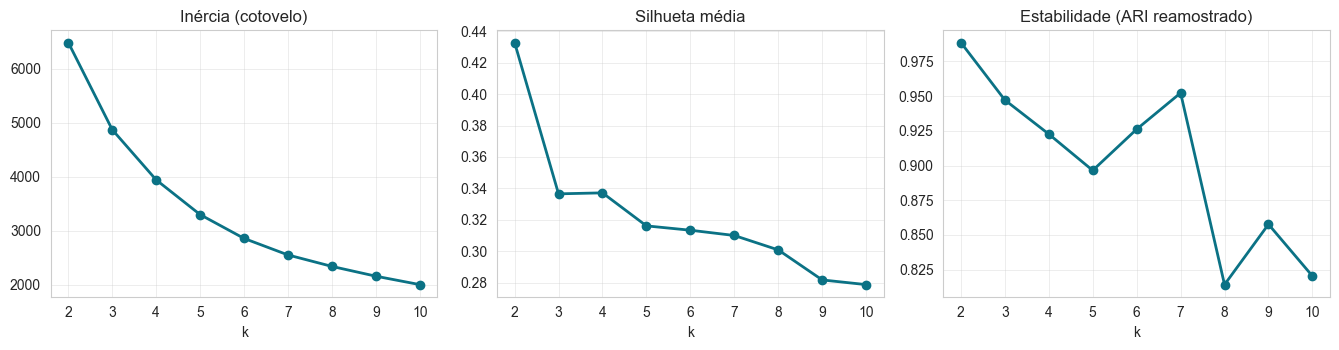

k de maior silhueta: 2 (não usado como K final — ver decisão na célula seguinte)


In [719]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
for ax, val, titulo in zip(axes, [inercia, silhueta_k, estab_k],
                           ["Inércia (cotovelo)", "Silhueta média", "Estabilidade (ARI reamostrado)"]):
    ax.plot(list(ks), val, "o-", color=PALETA[0], lw=2, ms=6)
    ax.set_xlabel("k")
    ax.set_title(titulo)
fig.tight_layout()
plt.show()

k_silhueta = list(ks)[int(np.argmax(silhueta_k))]
print(f"k de maior silhueta: {k_silhueta} (não usado como K final — ver decisão na célula seguinte)")

In [720]:
# K_FINAL = 4, cruzando as três métricas da seção anterior:
# - silhueta:     k=2 tem o pico (0.43), mas k=4 (0.34) ainda está na parte alta
#                 da curva, antes de cair para os valores fracos do fim da tabela
# - inércia:      a queda já desacelerou bastante em k=4 — ganho marginal pequeno
#                 frente ao salto grande de k=2 → k=3
# - estabilidade: ARI≈0.92, alto e reproduzível, longe do mergulho de k=8 (0.81)
# desempate de negócio: k=4 é o suficiente para os arquétipos de RFM
# (Champions/Loyal/At Risk/Lost) sem fragmentar demais
K_FINAL = 4

t0 = time.time()
km_final = KMeans(K_FINAL, n_init=20, random_state=RS).fit(Z)
registrar(f"K-Means (k={K_FINAL})", km_final.labels_, Z, time.time() - t0)
rfm["cluster_kmeans"] = km_final.labels_
print(f"K-Means final: k={K_FINAL}, silhueta={silhouette_score(Z, km_final.labels_):.3f}")

K-Means final: k=4, silhueta=0.337


### 4.2 · Clustering Hierárquico — linkage e dendrograma

In [721]:
# gargalo de memória do hierárquico é O(n²) — amostra se a base for grande
N_MAX_HIERARQUICO = 5000
if len(Z) > N_MAX_HIERARQUICO:
    idx_amostra = np.random.default_rng(RS).choice(len(Z), N_MAX_HIERARQUICO, replace=False)
    Z_hier = Z[idx_amostra]
    print(f"amostrando {N_MAX_HIERARQUICO} de {len(Z)} clientes para o hierárquico (custo de memória)")
else:
    Z_hier = Z
    idx_amostra = np.arange(len(Z))

silhueta_linkage = {}
for linkage_m in ["ward", "complete", "average"]:
    Z_link = linkage(Z_hier, method=linkage_m)
    labels_h = fcluster(Z_link, t=K_FINAL, criterion="maxclust")
    sil_h = silhouette_score(Z_hier, labels_h)
    silhueta_linkage[linkage_m] = sil_h
    print(f"linkage={linkage_m:<9} silhueta={sil_h:.3f}")
    t0 = time.time()
    registrar(f"Hierárquico ({linkage_m})", labels_h, Z_hier, time.time() - t0)

# linkage de maior silhueta — usado no dendrograma da célula seguinte,
# em vez de fixar Ward por padrão
LINKAGE_FINAL = max(silhueta_linkage, key=silhueta_linkage.get)
print(f"\nlinkage escolhido para o dendrograma: {LINKAGE_FINAL} "
      f"(silhueta={silhueta_linkage[LINKAGE_FINAL]:.3f})")

linkage=ward      silhueta=0.242
linkage=complete  silhueta=0.280
linkage=average   silhueta=0.416

linkage escolhido para o dendrograma: average (silhueta=0.416)


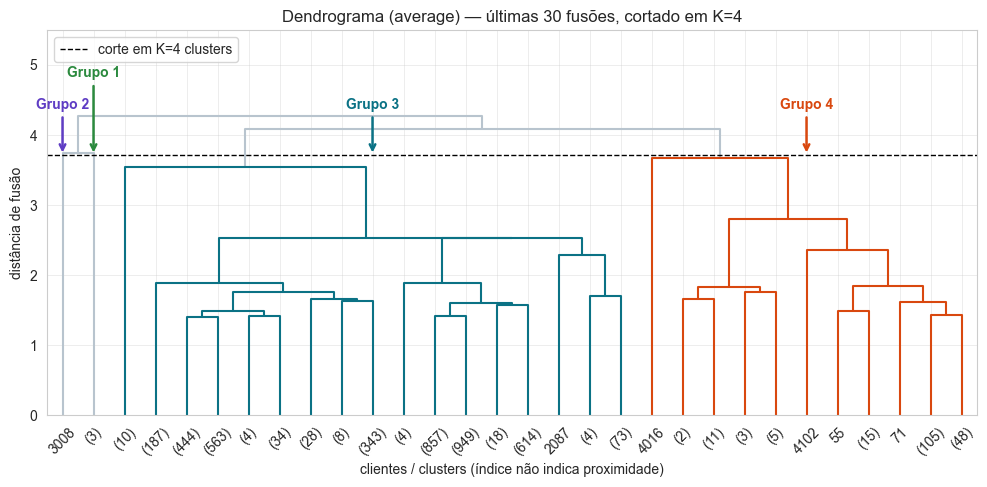

In [722]:
# dendrograma com o linkage que teve maior silhueta na comparação acima —
# Ward costuma ser o ponto de partida mais comum, mas usar aqui o vencedor
# real evita a inconsistência de comparar os três e ignorar o resultado
Z_link_final = linkage(Z_hier, method=LINKAGE_FINAL)
labels_hier_final = fcluster(Z_link_final, t=K_FINAL, criterion="maxclust")
rfm.loc[rfm.index[idx_amostra], "cluster_hier"] = labels_hier_final

# altura de corte que produz exatamente K_FINAL clusters — ponto médio entre a
# última fusão "aceita" (ainda gera K_FINAL grupos) e a próxima (juntaria dois deles)
n = len(Z_hier)
dist_ordenadas = Z_link_final[:, 2]
corte = (dist_ordenadas[n - K_FINAL - 1] + dist_ordenadas[n - K_FINAL]) / 2

# a cor de cada galho é decidida por nós (via link_color_func), não pelo esquema
# automático do scipy — com truncate_mode="lastp" a separação real entre clusters
# pode ficar escondida dentro de uma super-folha comprimida, e a cor automática do
# scipy (baseada só no desenho truncado) pode contar grupos errado ou usar cores
# pouco distintas; aqui a cor de cada galho vem do cluster real (fcluster) dos
# clientes originais por trás dele, então linha e rótulo sempre batem
_cache_indices = {}
def indices_originais(node_id):
    if node_id < n:
        return [node_id]
    if node_id in _cache_indices:
        return _cache_indices[node_id]
    esq, dir_ = int(Z_link_final[node_id - n, 0]), int(Z_link_final[node_id - n, 1])
    res = indices_originais(esq) + indices_originais(dir_)
    _cache_indices[node_id] = res
    return res

_cor_por_cluster = {}
def cor_do_cluster(grupo):
    if grupo not in _cor_por_cluster:
        _cor_por_cluster[grupo] = PALETA[len(_cor_por_cluster) % len(PALETA)]
    return _cor_por_cluster[grupo]

def link_color_func(node_id):
    if Z_link_final[node_id - n, 2] > corte:
        return CINZA_RUIDO
    idx_orig = indices_originais(node_id)
    valores, contagens = np.unique(labels_hier_final[idx_orig], return_counts=True)
    return cor_do_cluster(valores[np.argmax(contagens)])

fig, ax = plt.subplots(figsize=(12, 5))
ddata = dendrogram(Z_link_final, truncate_mode="lastp", p=30, ax=ax, link_color_func=link_color_func)
ax.axhline(corte, color="black", linestyle="--", lw=1, label=f"corte em K={K_FINAL} clusters")

# grupo de cada folha exibida via índices originais (não via cor desenhada) — evita
# contar clusters errado quando a compressão do truncate_mode esconde a separação real
grupo_por_folha = []
for node_id in ddata["leaves"]:
    idx_orig = indices_originais(node_id)
    valores, contagens = np.unique(labels_hier_final[idx_orig], return_counts=True)
    grupo_por_folha.append(valores[np.argmax(contagens)])

grupo_atual = grupo_por_folha[0]
inicio = 0
segmentos = []
for i, g in enumerate(grupo_por_folha[1:], start=1):
    if g != grupo_atual:
        segmentos.append((grupo_atual, inicio, i - 1))
        grupo_atual = g
        inicio = i
segmentos.append((grupo_atual, inicio, len(grupo_por_folha) - 1))

# escalona a altura do rótulo quando dois grupos ficam próximos demais no eixo X
# (grupos minúsculos, tipo um outlier isolado ao lado de um cluster de 3 clientes,
# senão as setas e os textos se sobrepõem)
y_topo = ax.get_ylim()[1]
x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
DIST_MIN = x_range * 0.08

x_centros = [5 + 10 * (ini + fim) / 2 for _, ini, fim in segmentos]
niveis = [0]
for i in range(1, len(x_centros)):
    niveis.append(niveis[i - 1] + 1 if x_centros[i] - x_centros[i - 1] < DIST_MIN else 0)

for (g, ini, fim), x_centro, nivel in zip(segmentos, x_centros, niveis):
    cor = cor_do_cluster(g)
    y_texto = corte + (0.15 + 0.10 * nivel) * y_topo
    ax.annotate(
        f"Grupo {g}", xy=(x_centro, corte), xytext=(x_centro, y_texto),
        ha="center", fontsize=10, fontweight="bold", color=cor,
        arrowprops=dict(arrowstyle="->", color=cor, lw=1.8),
    )

ax.set_ylim(0, corte + (0.15 + 0.10 * max(niveis) + 0.15) * y_topo)
ax.set_title(f"Dendrograma ({LINKAGE_FINAL}) — últimas 30 fusões, cortado em K={K_FINAL}")
ax.set_xlabel("clientes / clusters (índice não indica proximidade)")
ax.set_ylabel("distância de fusão")
ax.legend(loc="upper left")
plt.show()

### 4.3 · DBSCAN — k-distance graph para escolher `eps`

`MinPts` pela regra prática (≈2× dimensões); `eps` lido no "joelho" da curva k-distance.

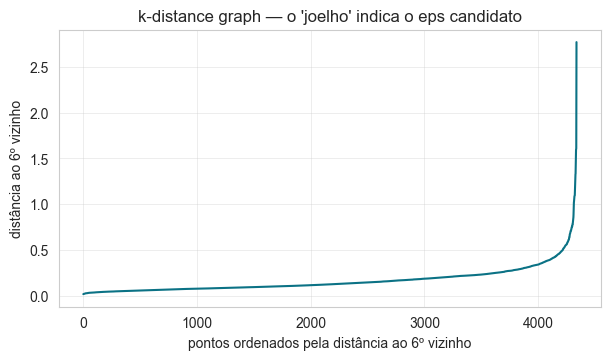

MinPts = 6
eps candidato (joelho via distância à corda) = 0.390 (ponto 4103 de 4338)


In [723]:
min_pts = 2 * Z.shape[1]
nn = NearestNeighbors(n_neighbors=min_pts).fit(Z)
dist_k, _ = nn.kneighbors(Z)
kdist = np.sort(dist_k[:, -1])

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(kdist, color=PALETA[0])
ax.set_xlabel(f"pontos ordenados pela distância ao {min_pts}º vizinho")
ax.set_ylabel(f"distância ao {min_pts}º vizinho")
ax.set_title("k-distance graph — o 'joelho' indica o eps candidato")
plt.show()

# heurística do "ponto mais distante da corda" (Kneedle): traça uma linha reta do
# primeiro ao último ponto da curva e acha o ponto que mais se afasta dela — mais
# robusto que "maior salto entre pontos consecutivos", que se deixa enganar por um
# disparo isolado bem no fim da cauda (poucos outliers extremos, não o joelho real)
x_norm = np.linspace(0, 1, len(kdist))
y_norm = (kdist - kdist.min()) / (kdist.max() - kdist.min())
corda = np.array([x_norm[-1], y_norm[-1]]) - np.array([x_norm[0], y_norm[0]])
corda_unit = corda / np.linalg.norm(corda)
pontos = np.stack([x_norm, y_norm], axis=1) - np.array([x_norm[0], y_norm[0]])
proj = pontos @ corda_unit
dist_perp = np.linalg.norm(pontos - np.outer(proj, corda_unit), axis=1)
idx_joelho = np.argmax(dist_perp)
eps_candidato = kdist[idx_joelho]

print(f"MinPts = {min_pts}")
print(f"eps candidato (joelho via distância à corda) = {eps_candidato:.3f} "
      f"(ponto {idx_joelho} de {len(kdist)})")

In [724]:
# validar eps: nem tudo virando ruído, nem tudo virando um cluster só
for eps in sorted({round(eps_candidato * f, 3) for f in (0.6, 0.8, 1.0, 1.2)}):
    db = DBSCAN(eps=eps, min_samples=min_pts).fit(Z)
    labels_db = db.labels_
    n_clusters_db = len(set(labels_db) - {-1})
    ruido_frac = (labels_db == -1).mean()
    print(f"eps={eps:<7} clusters={n_clusters_db:<3} ruído={ruido_frac:.1%}")

# EPS_FINAL = 0.8 × eps_candidato, cruzando clusters e ruído da tabela acima:
# - eps menor (0.6×) fragmenta demais (16 clusters) e marca ruído em excesso (11.9%) —
#   provavelmente cortando fino demais até dentro de grupos coesos
# - eps maior (1.0× e 1.2×) colapsa demais (3 e 2 clusters) — ruído baixo demais
#   pra ser crível como detecção de outliers de verdade
# - 0.8× é o equilíbrio: 6 clusters (granularidade comparável ao K-Means, K=4) e
#   5.8% de ruído (fração plausível de outliers genuínos)
EPS_FINAL = round(eps_candidato * 0.8, 3)
db_final = DBSCAN(eps=EPS_FINAL, min_samples=min_pts).fit(Z)
rfm["cluster_dbscan"] = db_final.labels_

t0 = time.time()
registrar(f"DBSCAN (eps={EPS_FINAL:.2f})", db_final.labels_, Z, time.time() - t0, apenas_nao_ruido=True)
print(f"\nDBSCAN final: {len(set(db_final.labels_) - {-1})} clusters, "
      f"{(db_final.labels_ == -1).mean():.1%} classificados como ruído (clientes atípicos)")

eps=0.234   clusters=16  ruído=11.9%
eps=0.312   clusters=6   ruído=5.8%
eps=0.39    clusters=3   ruído=3.0%
eps=0.468   clusters=2   ruído=1.7%

DBSCAN final: 6 clusters, 5.8% classificados como ruído (clientes atípicos)


**Cruzamento K-Means × DBSCAN** — para sustentar com dados (não só inferência) a leitura de que os 6 clusters de densidade do DBSCAN podem indicar sub-estrutura dentro dos 4 segmentos do K-Means.

In [725]:
crosstab_kmeans_dbscan = pd.crosstab(
    rfm["cluster_kmeans"], rfm["cluster_dbscan"], margins=True, margins_name="Total"
)
crosstab_kmeans_dbscan

cluster_dbscan,-1,0,1,2,3,4,5,Total
cluster_kmeans,,,,,,,,
0,28,3,1179,59,348,0,0,1617
1,56,659,20,288,153,0,0,1176
2,44,96,261,130,309,0,0,840
3,123,565,0,1,0,10,6,705
Total,251,1323,1460,478,810,10,6,4338


### 4.4 · Tabela comparativa

In [726]:
tabela_comparativa = pd.DataFrame(resultados).round(3)
tabela_comparativa

,algoritmo,n_clusters,silhouette,davies_bouldin,calinski_harabasz,tempo_execucao_s
0,K-Means (k=4),4,0.337,1.012,3329.154,0.132
1,Hierárquico (ward),4,0.242,1.120,2615.052,0.000
2,Hierárquico (complete),4,0.280,1.005,1734.101,0.000
3,Hierárquico (average),4,0.416,0.532,396.624,0.000
4,DBSCAN (eps=0.31),6,0.105,1.746,1119.171,0.000


## 5 · Diagnóstico de confiança

Antes de interpretar qualquer cluster: existe estrutura real nos dados, ou o algoritmo está "inventando" grupos em ruído (uma armadilha clássica do clustering)?

In [727]:
def hopkins(X, frac=0.1, seed=RS):
    '''~0.5 = sem estrutura de agrupamento; próximo de 1 = estrutura forte.'''
    r = np.random.default_rng(seed)
    n, d = X.shape
    m = max(int(frac * n), 5)
    amostra = X[r.choice(n, m, replace=False)]
    aleatorios = r.uniform(X.min(0), X.max(0), size=(m, d))
    nn2 = NearestNeighbors(n_neighbors=2).fit(X)
    u_dist, _ = nn2.kneighbors(aleatorios)
    w_dist, _ = nn2.kneighbors(amostra)
    U = u_dist[:, 0].sum()
    W = w_dist[:, 1].sum()  # segundo vizinho: o primeiro é o próprio ponto da amostra
    return U / (U + W)

h = hopkins(Z)
print(f"estatística de Hopkins: {h:.3f}  ({'indica estrutura' if h > 0.7 else 'estrutura fraca ou ausente — reavaliar'})")

estatística de Hopkins: 0.941  (indica estrutura)


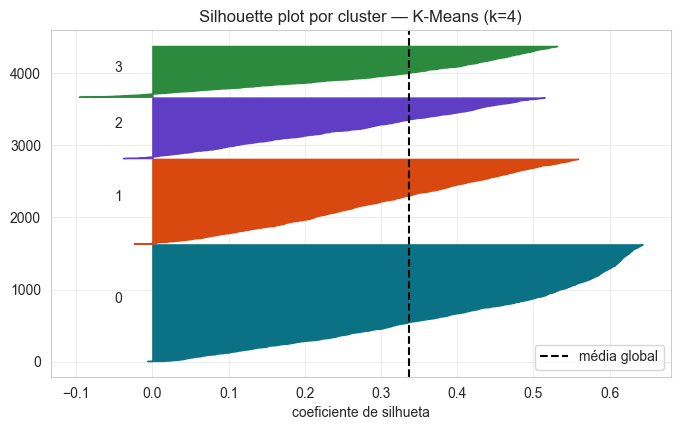

In [728]:
# silhouette plot por cluster — a média global (tabela da seção 4.4) pode esconder
# um cluster inteiro mal formado
sample_sil = silhouette_samples(Z, km_final.labels_)

fig, ax = plt.subplots(figsize=(8, 4.5))
y_lower = 10
for c in sorted(set(km_final.labels_)):
    vals = np.sort(sample_sil[km_final.labels_ == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=PALETA[c % len(PALETA)])
    ax.text(-0.05, y_lower + len(vals) / 2, str(c))
    y_lower = y_upper + 10
ax.axvline(silhouette_score(Z, km_final.labels_), color="black", linestyle="--", label="média global")
ax.set_xlabel("coeficiente de silhueta")
ax.set_title(f"Silhouette plot por cluster — K-Means (k={K_FINAL})")
ax.legend()
plt.show()

In [729]:
# estabilidade do K final escolhido — mesma lógica da seção 4.1, reportada para o modelo escolhido
print(f"estabilidade (ARI médio, reamostragem 80%, 20 repetições) do k={K_FINAL}: "
      f"{estabilidade(Z, K_FINAL):.3f}")

estabilidade (ARI médio, reamostragem 80%, 20 repetições) do k=4: 0.923


## 6 · Item 2 — Visualização e interpretação de clusters

Modelo usado como referência para as visualizações e o relatório: **K-Means final** (`km_final`, k=4).

variância explicada: [0.751 0.188 0.061]  (acumulada: [0.751 0.939 1.   ])


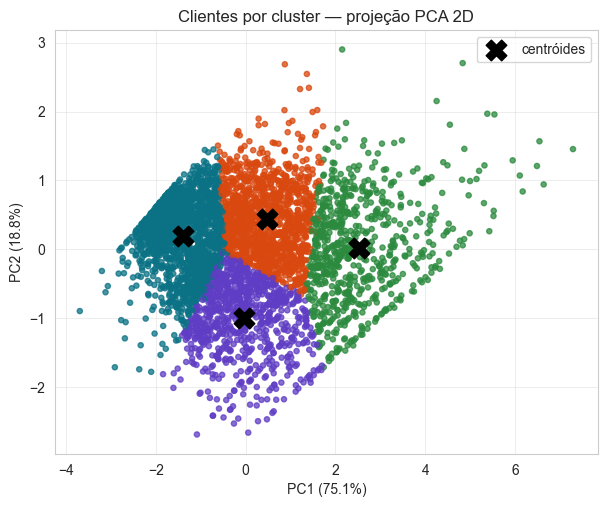

In [730]:
pca = PCA(n_components=3, random_state=RS).fit(Z)
Z_pca = pca.transform(Z)
cent_pca = pca.transform(km_final.cluster_centers_)
print(f"variância explicada: {pca.explained_variance_ratio_.round(3)}  "
      f"(acumulada: {pca.explained_variance_ratio_.cumsum().round(3)})")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(Z_pca[:, 0], Z_pca[:, 1], c=cores(km_final.labels_), s=14, alpha=0.75)
ax.scatter(cent_pca[:, 0], cent_pca[:, 1], marker="X", s=220, c="black", label="centróides")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Clientes por cluster — projeção PCA 2D")
ax.legend()
plt.show()

**Interpretação dos componentes principais** — os *loadings* mostram o peso de cada feature original (Recency, Frequency, Monetary) em cada componente, permitindo dizer o que PC1 e PC2 representam em termos de negócio, não só em % de variância.

In [731]:
loadings = pd.DataFrame(
    pca.components_.T, index=FEATURES, columns=["PC1", "PC2", "PC3"]
).round(3)
loadings

,PC1,PC2,PC3
Recency,-0.512,0.850,0.126
Frequency,0.618,0.262,0.741
Monetary,0.597,0.457,-0.659


In [732]:
fig3d = go.Figure(data=[go.Scatter3d(
    x=Z_pca[:, 0], y=Z_pca[:, 1], z=Z_pca[:, 2],
    mode="markers",
    marker=dict(size=3, color=km_final.labels_, colorscale="Viridis", opacity=0.8),
)])
fig3d.update_layout(
    title="Clientes por cluster — projeção PCA 3D",
    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
    width=750, height=550,
)
fig3d.show()

In [733]:
# perfil por cluster (medianas na escala original — mais interpretável que Z)
perfil = rfm.groupby("cluster_kmeans")[FEATURES].median()

# normaliza em espaço log1p, não na escala original — um único cluster extremo em
# Frequency/Monetary (mesmo problema de escala da seção 3) dominaria o min-max e
# esmagaria a diferença visual entre os outros clusters, mesmo eles sendo bem diferentes entre si
perfil_log = np.log1p(perfil)
perfil_norm = (perfil_log - perfil_log.min()) / (perfil_log.max() - perfil_log.min())

fig_radar = go.Figure()
for c in perfil_norm.index:
    fig_radar.add_trace(go.Scatterpolar(
        r=perfil_norm.loc[c].values, theta=FEATURES, fill="toself", name=f"Cluster {c}",
    ))
fig_radar.update_layout(
    title="Perfil normalizado por cluster (mediana de R, F, M)",
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    width=650, height=550,
)
fig_radar.show()

In [734]:
# tabela crua (sem normalizar) — útil para conferir se algum cluster é extremo
# de verdade, em vez de artefato de escala do gráfico
perfil.assign(clientes=rfm["cluster_kmeans"].value_counts())

,Recency,Frequency,Monetary,clientes
cluster_kmeans,,,,
0,177.0,1.0,300.360,1617
1,54.0,4.0,1355.035,1176
2,17.0,2.0,468.335,840
3,8.0,10.0,3738.400,705


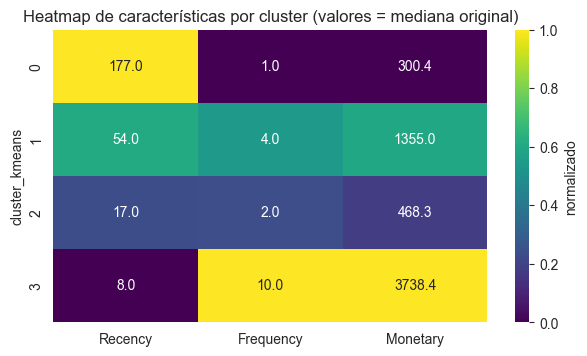

In [735]:
fig, ax = plt.subplots(figsize=(7, 3.8))
sns.heatmap(perfil_norm, annot=perfil.round(1), fmt="", cmap="viridis", ax=ax, cbar_kws={"label": "normalizado"})
ax.set_title("Heatmap de características por cluster (valores = mediana original)")
plt.show()

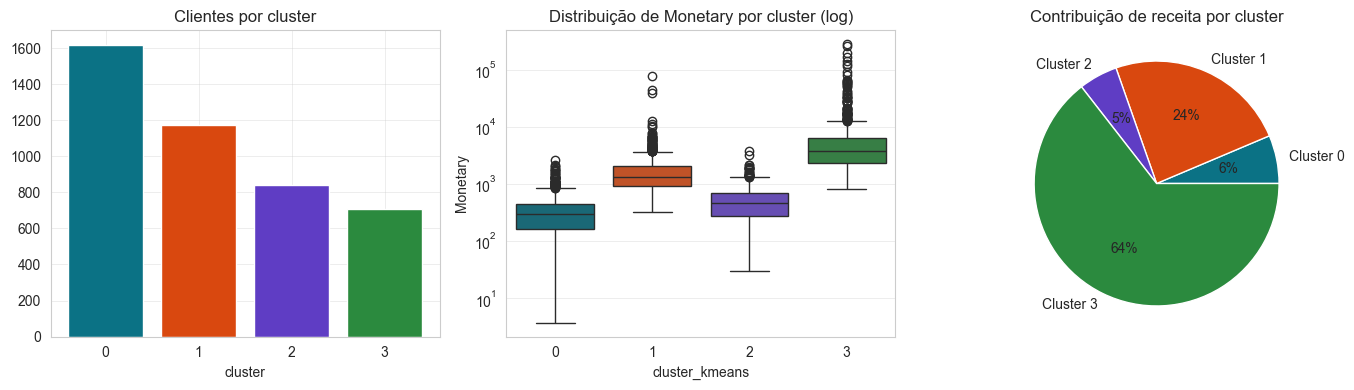

In [736]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

contagem = rfm["cluster_kmeans"].value_counts().sort_index()
axes[0].bar(contagem.index.astype(str), contagem.values, color=PALETA[:len(contagem)])
axes[0].set_title("Clientes por cluster")
axes[0].set_xlabel("cluster")

sns.boxplot(data=rfm, x="cluster_kmeans", y="Monetary", ax=axes[1], palette=PALETA)
axes[1].set_yscale("log")
axes[1].set_title("Distribuição de Monetary por cluster (log)")

receita_cluster = rfm.groupby("cluster_kmeans")["Monetary"].sum()
axes[2].pie(receita_cluster.values, labels=[f"Cluster {c}" for c in receita_cluster.index],
            autopct="%1.0f%%", colors=PALETA[:len(receita_cluster)])
axes[2].set_title("Contribuição de receita por cluster")

fig.tight_layout()
plt.show()

## 7 · Nomeação dos clusters — traduzir para negócio

Regra simples baseada na posição de cada cluster frente à mediana global de R, F e M (ajustar os limiares depois de olhar a tabela `perfil` da seção 6 — a regra abaixo é um ponto de partida, não verdade absoluta).

In [737]:
def nomear_cluster(row, ref):
    recency_baixa = row["Recency"] <= ref["Recency"].median()
    frequency_alta = row["Frequency"] >= ref["Frequency"].median()
    monetary_alto = row["Monetary"] >= ref["Monetary"].median()
    if recency_baixa and frequency_alta and monetary_alto:
        return "Champions"
    if recency_baixa and frequency_alta:
        return "Loyal Customers"
    if not recency_baixa and (frequency_alta or monetary_alto):
        return "At Risk"
    if recency_baixa and not frequency_alta:
        return "New Customers"
    return "Lost"

nomes_cluster = perfil.apply(lambda row: nomear_cluster(row, rfm), axis=1)
perfil_nomeado = perfil.copy()
perfil_nomeado["nome"] = nomes_cluster
perfil_nomeado["clientes"] = contagem
perfil_nomeado["receita_total"] = receita_cluster
perfil_nomeado["receita_%"] = (receita_cluster / receita_cluster.sum() * 100).round(1)
perfil_nomeado.sort_values("receita_total", ascending=False)

,Recency,Frequency,Monetary,nome,clientes,receita_total,receita_%
cluster_kmeans,,,,,,,
3,8.0,10.0,3738.400,Champions,705,5746587.340,64.5
1,54.0,4.0,1355.035,At Risk,1176,2139968.933,24.0
0,177.0,1.0,300.360,Lost,1617,567548.431,6.4
2,17.0,2.0,468.335,Loyal Customers,840,457303.200,5.1


### 7.1 · Taxa de cancelamento por segmento

Overlay sobre os clusters já formados — não muda o RFM nem o agrupamento, só adiciona uma leitura de risco em cima dos segmentos existentes.
Calculada a partir do `df_raw` (antes do filtro de cancelamentos aplicado na seção 1), como `pedidos cancelados / pedidos totais` por cliente.

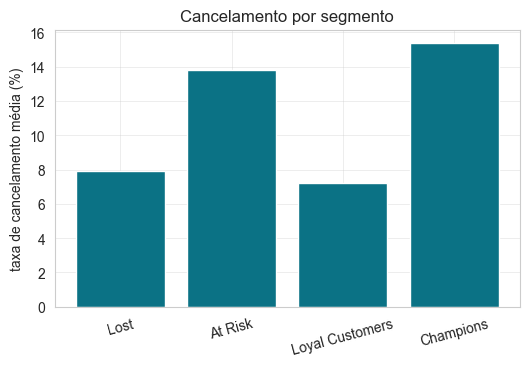

,nome,clientes,receita_%,taxa_cancelamento_%
cluster_kmeans,,,,
3,Champions,705,64.5,15.4
1,At Risk,1176,24.0,13.8
0,Lost,1617,6.4,7.9
2,Loyal Customers,840,5.1,7.2


In [738]:
# taxa de cancelamento por cliente — usa df_raw (tem os pedidos "C..." que df já descartou)
df_com_cliente = df_raw.dropna(subset=["CustomerID"]).copy()
df_com_cliente["CustomerID"] = df_com_cliente["CustomerID"].astype(int)
df_com_cliente["cancelado"] = df_com_cliente["InvoiceNo"].astype(str).str.startswith("C")

pedidos = df_com_cliente.drop_duplicates("InvoiceNo")[["InvoiceNo", "CustomerID", "cancelado"]]
taxa_cancelamento = pedidos.groupby("CustomerID").agg(
    pedidos_totais=("InvoiceNo", "nunique"),
    pedidos_cancelados=("cancelado", "sum"),
)
taxa_cancelamento["taxa_cancelamento"] = (
    taxa_cancelamento["pedidos_cancelados"] / taxa_cancelamento["pedidos_totais"]
)

rfm = rfm.merge(taxa_cancelamento["taxa_cancelamento"], on="CustomerID", how="left")
perfil_nomeado["taxa_cancelamento_%"] = (
    rfm.groupby("cluster_kmeans")["taxa_cancelamento"].mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(perfil_nomeado["nome"], perfil_nomeado["taxa_cancelamento_%"], color=PALETA[0])
ax.set_ylabel("taxa de cancelamento média (%)")
ax.set_title("Cancelamento por segmento")
plt.xticks(rotation=15)
plt.show()

perfil_nomeado[["nome", "clientes", "receita_%", "taxa_cancelamento_%"]].sort_values(
    "taxa_cancelamento_%", ascending=False
)

## 8 · Item 3 — Insumos para o relatório executivo

O relatório executivo em si **não fica neste notebook** — é um documento separado (`relatorio_executivo.docx`), pensado para leitura por quem não vai abrir código. A célula abaixo só calcula e imprime os números que entram nele; copie-os para o `.docx` e complete os `[colchetes]` de leitura de negócio.

In [739]:
maior_cluster = perfil_nomeado["clientes"].idxmax()
maior_receita = perfil_nomeado["receita_total"].idxmax()
risco_clusters = perfil_nomeado[perfil_nomeado["nome"].isin(["At Risk", "Lost"])]

print("=== Copiar para relatorio_executivo.docx ===\n")
print(f"K_FINAL usado                 : {K_FINAL}")
print(f"Silhouette (K-Means final)    : {silhouette_score(Z, km_final.labels_):.3f}")
print(f"Estabilidade (ARI reamostrado): {estabilidade(Z, K_FINAL):.3f}")
print(f"Data de referência (RFM)      : {data_referencia.date()}")
print()
print(f"Segmento de maior receita     : {perfil_nomeado.loc[maior_receita, 'nome']} "
      f"({perfil_nomeado.loc[maior_receita, 'receita_%']:.0f}% da receita, "
      f"{perfil_nomeado.loc[maior_receita, 'clientes']} clientes)")
print(f"Segmentos em risco/perdidos   : {len(risco_clusters)} segmento(s), "
      f"{risco_clusters['clientes'].sum()} clientes")
print()
print("Tabela completa por segmento (para a tabela do relatório):")
perfil_nomeado.sort_values("receita_total", ascending=False)

=== Copiar para relatorio_executivo.docx ===

K_FINAL usado                 : 4
Silhouette (K-Means final)    : 0.337
Estabilidade (ARI reamostrado): 0.923
Data de referência (RFM)      : 2011-12-10

Segmento de maior receita     : Champions (64% da receita, 705 clientes)
Segmentos em risco/perdidos   : 2 segmento(s), 2793 clientes

Tabela completa por segmento (para a tabela do relatório):


,Recency,Frequency,Monetary,nome,clientes,receita_total,receita_%,taxa_cancelamento_%
cluster_kmeans,,,,,,,,
3,8.0,10.0,3738.400,Champions,705,5746587.340,64.5,15.4
1,54.0,4.0,1355.035,At Risk,1176,2139968.933,24.0,13.8
0,177.0,1.0,300.360,Lost,1617,567548.431,6.4,7.9
2,17.0,2.0,468.335,Loyal Customers,840,457303.200,5.1,7.2


## 9 · Exportação para o dashboard

Gera `rfm_clusters.csv`, consumido pelo dashboard Streamlit (`app.py`, entregue à parte). Rodar `streamlit run app.py` na mesma pasta onde este CSV foi salvo (dentro de `data/`).

In [740]:
import os

os.makedirs("data", exist_ok=True)

rfm_export = rfm.copy()
rfm_export["PC1"] = Z_pca[:, 0]
rfm_export["PC2"] = Z_pca[:, 1]
rfm_export["segmento"] = rfm_export["cluster_kmeans"].map(perfil_nomeado["nome"])

colunas_export = ["CustomerID", "Recency", "Frequency", "Monetary", "PC1", "PC2", "segmento"]
rfm_export[colunas_export].to_csv("data/rfm_clusters.csv", index=False)

print(f"exportado: data/rfm_clusters.csv ({len(rfm_export)} linhas)")
rfm_export[colunas_export].head()

exportado: data/rfm_clusters.csv (4338 linhas)


,CustomerID,Recency,Frequency,Monetary,PC1,PC2,segmento
0,12346,326,1,77183.60,0.872658,2.686758,At Risk
1,12347,2,7,4310.00,2.550260,-0.804427,Champions
2,12348,75,4,1797.24,0.475142,0.746121,At Risk
3,12349,19,1,1757.55,0.145832,-0.460480,Loyal Customers
4,12350,310,1,334.40,-1.688990,0.676555,Lost
